# 06 — E-Iso-1..8: Fault Injection & Attack Containment

RFC-008 §D8. Six attack scenarios in position 2 of a 3-node linear pipeline,
plus diamond-topology branch isolation (E-Iso-7) and recovery-time measurement (E-Iso-8).
Each attack traps on every `process()` call; the isolation invariant is:
source throughput unaffected, attack contained, no cross-node contamination.

**Inputs**: `eval/results/e-iso-{1..6}/shakedown-macos-<ts>/` produced by
`eval/scripts/run-e-iso-shakedown.sh --all`.

In [1]:
import json, os, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

ATTACKS = [
    ('buffer-overflow', 1),
    ('cross-read', 2),
    ('fs-access', 3),
    ('infinite-loop', 4),
    ('memory-exhaust', 5),
    ('panic', 6),
]

def find_shakedown(iso_num):
    """Find the newest shakedown directory for a given E-Iso experiment."""
    pattern = str(REPO / f'eval/results/e-iso-{iso_num}/shakedown-macos-*')
    candidates = sorted(glob.glob(pattern))
    if not candidates:
        return None
    return Path(candidates[-1])

# Load all shakedown results
results = []
for attack_name, iso_num in ATTACKS:
    sd = find_shakedown(iso_num)
    if sd is None:
        print(f'MISSING: e-iso-{iso_num} ({attack_name})')
        continue
    sj = sd / 'shakedown.json'
    if not sj.exists():
        print(f'MISSING shakedown.json: {sj}')
        continue
    data = json.loads(sj.read_text())
    data['attack_name'] = attack_name
    data['iso_num'] = iso_num
    data['shakedown_dir'] = str(sd)
    results.append(data)

df = pd.DataFrame(results)
print(f'Loaded {len(df)} attack results')
df[['attack_name', 'contained', 'source_throughput_pct', 'attacker_state', 'other_nodes_healthy']]

Loaded 6 attack results


,attack_name,contained,source_throughput_pct,attacker_state,other_nodes_healthy
0,buffer-overflow,True,100.0,Error/Recovering,True
1,cross-read,True,100.0,Error/Recovering,True
2,fs-access,True,100.0,Error/Recovering,True
3,infinite-loop,True,100.0,Error/Recovering,True
4,memory-exhaust,True,100.0,Error/Recovering,True
5,panic,True,100.0,Error/Recovering,True


## Per-node throughput timeline

For each attack, parse `stdout.log` to extract timestamps of ERROR events
(attack node traps) and show the source emitting at constant rate while the
attack node traps on every message.

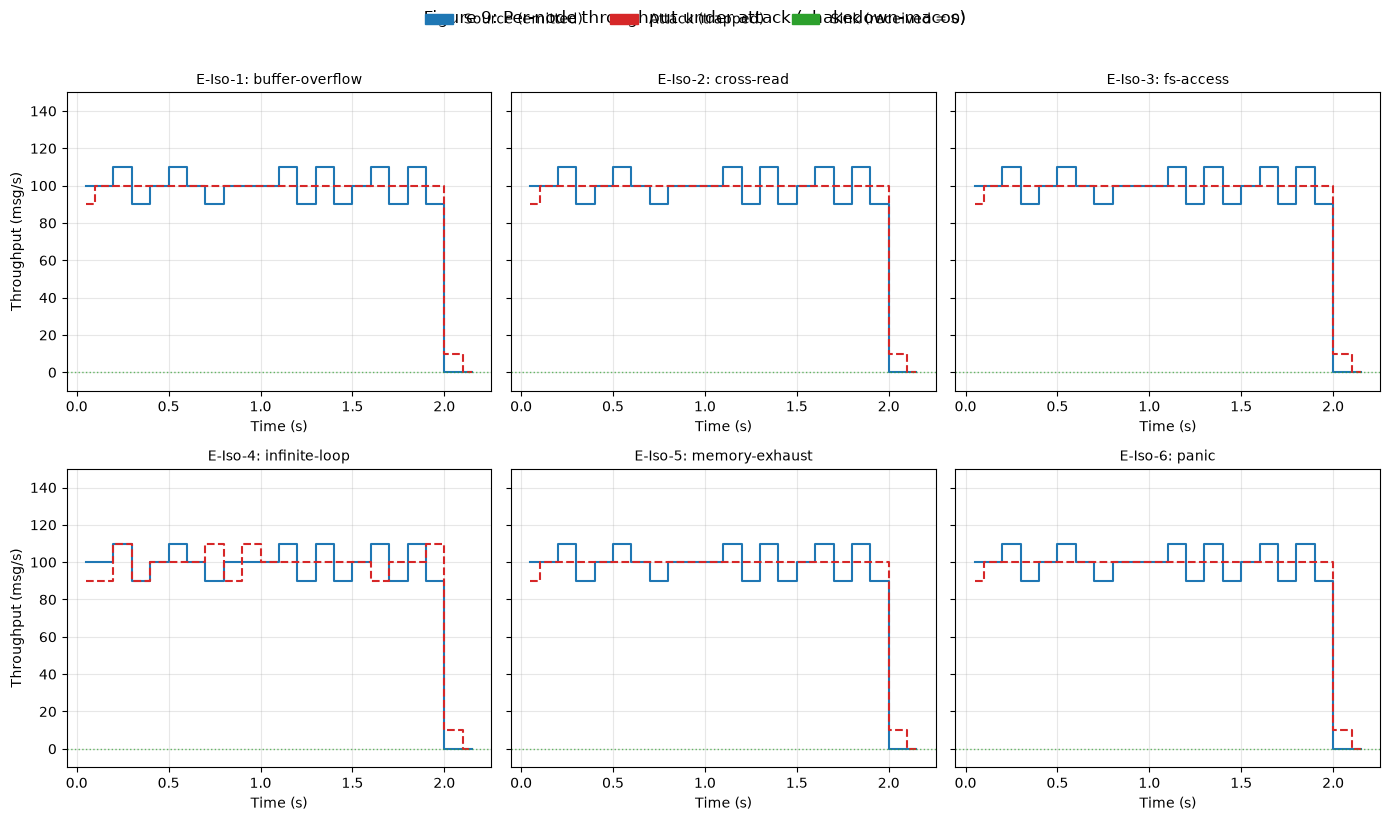

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes_flat = axes.flatten()

ANSI_RE = re.compile(r'\x1b\[[0-9;]*m')
TS_RE = re.compile(r'^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+Z)')

for idx, (attack_name, iso_num) in enumerate(ATTACKS):
    ax = axes_flat[idx]
    sd = find_shakedown(iso_num)
    if sd is None:
        ax.set_title(f'E-Iso-{iso_num}: MISSING')
        continue

    log_path = sd / 'run-1' / 'stdout.log'
    if not log_path.exists():
        ax.set_title(f'E-Iso-{iso_num}: no log')
        continue

    # Parse timestamps from log
    trap_times = []
    pipeline_start = None
    pipeline_end = None

    for line in log_path.read_text().splitlines():
        clean = ANSI_RE.sub('', line)
        m = TS_RE.match(clean)
        if not m:
            continue
        ts_str = m.group(1)
        if 'Pipeline running' in clean:
            pipeline_start = pd.Timestamp(ts_str)
        if 'Pipeline completed' in clean:
            pipeline_end = pd.Timestamp(ts_str)
        if 'unrecoverable error' in clean and 'node=' in clean:
            trap_times.append(pd.Timestamp(ts_str))

    if not pipeline_start or not trap_times:
        ax.set_title(f'E-Iso-{iso_num}: no data')
        continue

    # Convert to relative seconds
    trap_secs = np.array([(t - pipeline_start).total_seconds() for t in trap_times])
    end_sec = (pipeline_end - pipeline_start).total_seconds() if pipeline_end else trap_secs[-1] + 0.1

    # Source emits at constant rate: 100 msg/s for 2s
    total_msgs = 200
    source_rate = 100.0
    source_times = np.array([i / source_rate for i in range(total_msgs)])

    # Bin into 100ms windows for throughput
    bin_width = 0.1
    max_t = max(end_sec, source_times[-1]) + bin_width
    bins = np.arange(0, max_t + bin_width, bin_width)

    # Source throughput per bin
    src_counts, _ = np.histogram(source_times, bins=bins)
    src_thr = src_counts / bin_width

    # Attack trap throughput per bin
    trap_counts, _ = np.histogram(trap_secs, bins=bins)
    trap_thr = trap_counts / bin_width

    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.step(bin_centers, src_thr, where='mid', label='Source (emitted)', color='tab:blue', linewidth=1.5)
    ax.step(bin_centers, trap_thr, where='mid', label='Attack (traps)', color='tab:red', linewidth=1.5, linestyle='--')
    ax.axhline(y=0, color='tab:green', linewidth=1, linestyle=':', label='Sink (received)', alpha=0.7)

    ax.set_title(f'E-Iso-{iso_num}: {attack_name}', fontsize=10)
    ax.set_xlabel('Time (s)')
    if idx % 3 == 0:
        ax.set_ylabel('Throughput (msg/s)')
    ax.set_ylim(-10, 150)
    ax.grid(True, alpha=0.3)

# Shared legend
handles = [
    mpatches.Patch(color='tab:blue', label='Source (emitted)'),
    mpatches.Patch(color='tab:red', label='Attack (trapped)'),
    mpatches.Patch(color='tab:green', label='Sink (received = 0)'),
]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=10, frameon=False)
fig.suptitle('Figure 9: Per-node throughput under attack (shakedown-macos)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Summary table (readiness matrix)

Matches the format in `docs/status/canonical-readiness.md`.

In [3]:
summary = df[['attack_name', 'iso_num', 'contained', 'source_throughput_pct',
              'attacker_state', 'other_nodes_healthy', 'error_count', 'total_messages']].copy()
summary['status'] = summary.apply(
    lambda r: '\U0001f7e2' if r['contained'] and r['other_nodes_healthy'] else '\U0001f534', axis=1
)
summary = summary.rename(columns={
    'attack_name': 'Attack',
    'iso_num': 'E-Iso-N',
    'contained': 'Contained',
    'source_throughput_pct': 'Source Thr %',
    'attacker_state': 'Attacker State',
    'other_nodes_healthy': 'Healthy Nodes',
    'error_count': 'Traps',
    'total_messages': 'Total Msgs',
    'status': 'Status',
})
summary[['Status', 'Attack', 'E-Iso-N', 'Contained', 'Source Thr %', 'Attacker State', 'Traps', 'Healthy Nodes']]

,Status,Attack,E-Iso-N,Contained,Source Thr %,Attacker State,Traps,Healthy Nodes
0,🟢,buffer-overflow,1,True,100.0,Error/Recovering,200,True
1,🟢,cross-read,2,True,100.0,Error/Recovering,200,True
2,🟢,fs-access,3,True,100.0,Error/Recovering,200,True
3,🟢,infinite-loop,4,True,100.0,Error/Recovering,200,True
4,🟢,memory-exhaust,5,True,100.0,Error/Recovering,200,True
5,🟢,panic,6,True,100.0,Error/Recovering,200,True


In [4]:
# Verify all attacks are contained
assert df['contained'].all(), 'Not all attacks were contained!'
assert df['other_nodes_healthy'].all(), 'Some non-attack nodes reported errors!'
assert (df['source_throughput_pct'] >= 99.0).all(), 'Source throughput dropped below 99%!'
print('All 6 attacks CONTAINED. Source throughput >= 99% for all. No cross-node contamination.')

All 6 attacks CONTAINED. Source throughput >= 99% for all. No cross-node contamination.


## E-Iso-7: Diamond Topology Fault Isolation

Branch-A (healthy pass-through) vs Branch-B (panic attack) in a diamond
topology. The isolation invariant: branch-A throughput drops <1% when
branch-B traps on every message.

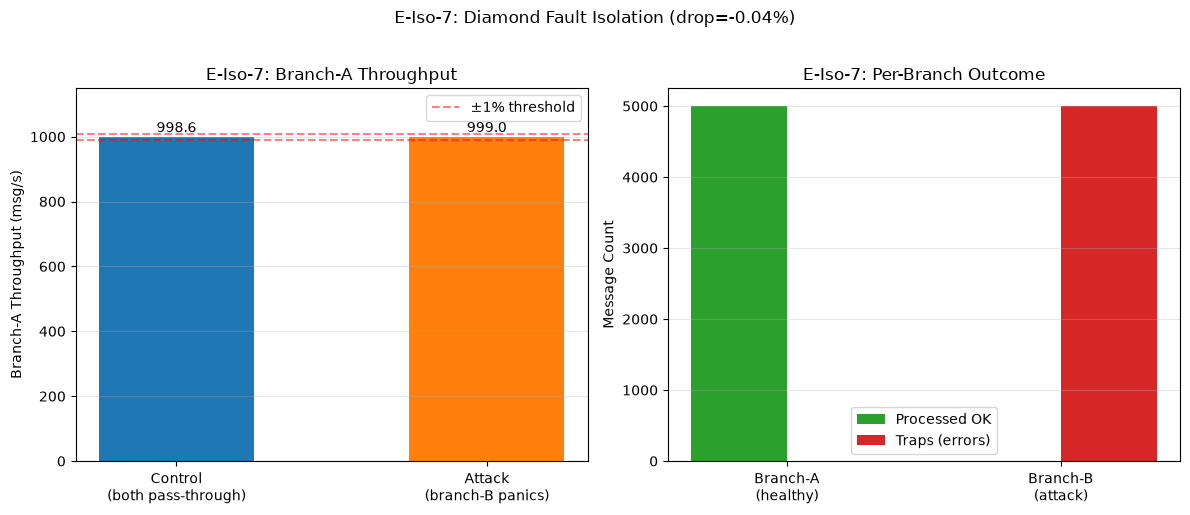

Branch-A throughput drop: -0.0400%
Contained: True


In [5]:
# E-Iso-7: Diamond fault isolation
iso7_dir = find_shakedown(7)

if iso7_dir is not None and (iso7_dir / 'shakedown.json').exists():
    iso7 = json.loads((iso7_dir / 'shakedown.json').read_text())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar chart: control vs attack throughput for branch-A
    labels = ['Control\n(both pass-through)', 'Attack\n(branch-B panics)']
    thr_values = [iso7['control_branch_a_thr'], iso7['attack_branch_a_thr']]
    colors = ['tab:blue', 'tab:orange']
    bars = ax1.bar(labels, thr_values, color=colors, width=0.5)
    ax1.set_ylabel('Branch-A Throughput (msg/s)')
    ax1.set_title('E-Iso-7: Branch-A Throughput')
    ax1.set_ylim(0, max(thr_values) * 1.15)
    
    # Annotate with values
    for bar, val in zip(bars, thr_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    # Add ±1% threshold lines
    ctrl_thr = iso7['control_branch_a_thr']
    ax1.axhline(y=ctrl_thr * 0.99, color='red', linestyle='--', alpha=0.5, label='±1% threshold')
    ax1.axhline(y=ctrl_thr * 1.01, color='red', linestyle='--', alpha=0.5)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Right panel: branch comparison (branch_a vs branch_b messages)
    nodes = ['Branch-A\n(healthy)', 'Branch-B\n(attack)']
    processed = [iso7['total_messages'], 0]
    traps = [iso7['branch_a_errors'], iso7['branch_b_traps']]
    
    x = np.arange(len(nodes))
    w = 0.35
    ax2.bar(x - w/2, processed, w, label='Processed OK', color='tab:green')
    ax2.bar(x + w/2, traps, w, label='Traps (errors)', color='tab:red')
    ax2.set_xticks(x)
    ax2.set_xticklabels(nodes)
    ax2.set_ylabel('Message Count')
    ax2.set_title('E-Iso-7: Per-Branch Outcome')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle(f'E-Iso-7: Diamond Fault Isolation (drop={iso7["branch_a_throughput_drop_pct"]:.2f}%)', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Branch-A throughput drop: {iso7['branch_a_throughput_drop_pct']:.4f}%")
    print(f"Contained: {abs(iso7['branch_a_throughput_drop_pct']) < 1.0}")
    assert abs(iso7['branch_a_throughput_drop_pct']) < 1.0, 'Branch-A throughput dropped >1%!'
else:
    print('E-Iso-7 results not found — run eval/scripts/run-e-iso-7-8.sh --iso 7')

## E-Iso-8: Recovery Time Histogram

Trap → Recovering → Running duration measured via
`wafer_node_recovery_duration_ms` Prometheus summary/histogram.
Recovery from `InstancePre` cache is sub-millisecond.

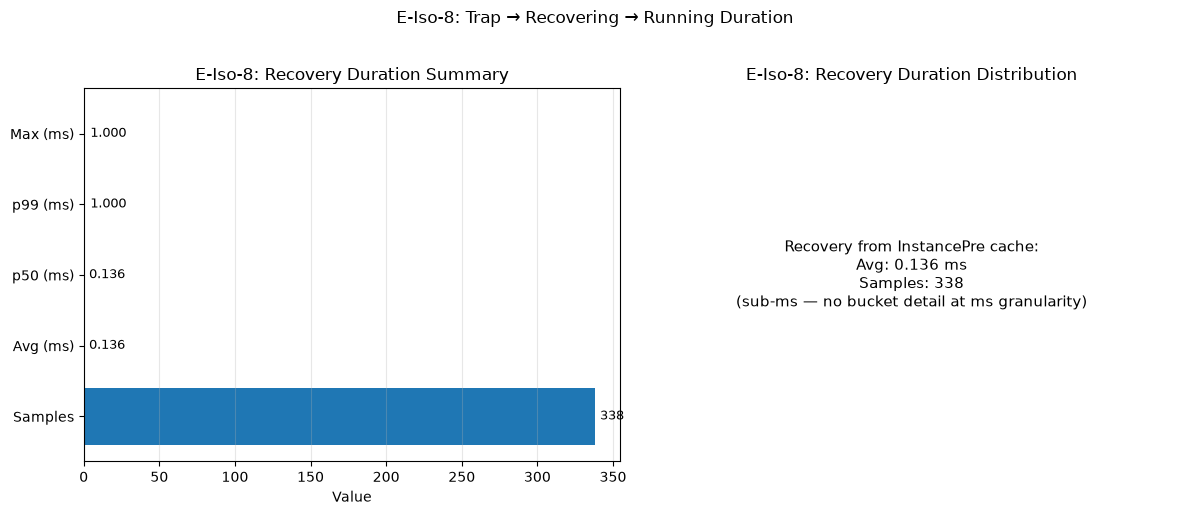

Recovery samples: 338
p50: 0.136 ms, p99: 1.0 ms
Note: avg recovery 0.136 ms from InstancePre cache


In [6]:
# E-Iso-8: Recovery time histogram
iso8_dir = find_shakedown(8)

if iso8_dir is not None and (iso8_dir / 'shakedown.json').exists():
    iso8 = json.loads((iso8_dir / 'shakedown.json').read_text())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left: recovery summary stats
    metrics = ['Samples', 'Avg (ms)', 'p50 (ms)', 'p99 (ms)', 'Max (ms)']
    values = [
        iso8['recovery_samples_count'],
        iso8['recovery_sum_ms'] / max(iso8['recovery_samples_count'], 1),
        iso8['recovery_p50_ms'],
        iso8['recovery_p99_ms'],
        iso8['recovery_max_ms']
    ]
    bars = ax1.barh(metrics, values, color=['tab:blue', 'tab:green', 'tab:green', 'tab:orange', 'tab:red'])
    ax1.set_xlabel('Value')
    ax1.set_title('E-Iso-8: Recovery Duration Summary')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_width() + 0.01 * max(values), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}' if val < 10 else f'{val:.0f}',
                ha='left', va='center', fontsize=9)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Right: bucket histogram if available, otherwise text summary
    run_dir = iso8_dir / 'run-1'
    hist_path = run_dir / 'recovery_histogram.json'
    if hist_path.exists():
        hist = json.loads(hist_path.read_text())
        if hist['buckets']:
            les = [b['le'] for b in hist['buckets']]
            counts = [b['count'] for b in hist['buckets']]
            ax2.bar(range(len(les)), counts, tick_label=[f'{l}ms' for l in les])
            ax2.set_xlabel('Bucket (le)')
            ax2.set_ylabel('Cumulative Count')
            ax2.set_title('Recovery Duration Buckets')
        else:
            ax2.text(0.5, 0.5, f"Recovery from InstancePre cache:\n"
                     f"Avg: {iso8['recovery_sum_ms']/max(iso8['recovery_samples_count'],1):.3f} ms\n"
                     f"Samples: {iso8['recovery_samples_count']}\n"
                     f"(sub-ms — no bucket detail at ms granularity)",
                     ha='center', va='center', fontsize=11, transform=ax2.transAxes)
            ax2.set_title('E-Iso-8: Recovery Duration Distribution')
            ax2.set_axis_off()
    else:
        ax2.text(0.5, 0.5, 'recovery_histogram.json not found',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_axis_off()
    
    fig.suptitle('E-Iso-8: Trap → Recovering → Running Duration', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"Recovery samples: {iso8['recovery_samples_count']}")
    print(f"p50: {iso8['recovery_p50_ms']} ms, p99: {iso8['recovery_p99_ms']} ms")
    if iso8.get('sub_ms_note'):
        print(f"Note: {iso8['sub_ms_note']}")
    assert iso8['recovery_samples_count'] > 0, 'No recovery samples!'
else:
    print('E-Iso-8 results not found — run eval/scripts/run-e-iso-7-8.sh --iso 8')